### Importing Dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Load Dataset

In [4]:
def load_dataset(file_path):
    df = pd.read_csv(file_path)
    return df

df = load_dataset('C:\\Users\\HP\\Downloads\\archive\\hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Dataset Overview

In [6]:
# Shape of the dataset
df.shape

(119390, 32)

In [7]:
# Columns of the dataset

df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### EDA

In [9]:
# Information of Data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

**Number of Entries:** The dataset consists of 119,390 entries.

**Columns:** The dataset contains 32 columns, which represent various attributes related to hotel bookings.

**Data Types:**

* 12 coumns are of the object data type

* 16 columns are of the int64 data type, representing integer values.

* 4 columns are of the float64 data type, which typically
 denotes decimal values.

In [11]:
# Descriptive Analysis

df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Based on the descriptions,the following features seem to contain noisy data:

**adr**: The Average Daily Rate (ADR) represents the average amount a guest pays for a room per day. In this dataset, ADR has a minimum value of -6.38. A negative rate doesn't make sense, indicating potential errors or special cases.

**adults,children,babies**: The minimum value is 0, which implies bookings without any adults. This could be a data entry error.

**children and babies**: Both have a maximum value of 10. This could be a potential outlier or data entry error.


In [13]:
# Descriptive Analysis of Categorical Columns

df.describe(include='O')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


**1.** There are 2 types of hotel, cityhotel was guest booked most.

**2.** There are different types of guests and most guests come from
    portugal.

**3.** Guests can choose different foods from the menu,most of them are choosed BB

**4.** Guests can book hotel directly or through different
    channels that are available,most of them are booking through TA/TO.


**5.** Guests can choose rooms of their liking while booking most of them choose room type A.


In [15]:
# Checking duplicates

df.duplicated().sum()

31994

In [16]:
# Dropping duplicates 

df.drop_duplicates(inplace= True)
df = df.reset_index(drop= True)

In [17]:
# checking after removing duplicates

df.duplicated().sum()

0

In [18]:
# Checking the null values

df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


**agent**: This feature has several unique categories, and some agents may only appear a few times in the dataset, which could cause overfitting.

**company**: This feature has a high percentage of missing values and may not be very informative for predicting cancellations, so it may be better to drop it entirely.

**reservation_status_date**: reservation_status_date is a date feature that indicates the latest date at which the reservation_status was updated.
 the data type is object.
 
**reservation_status** : reseration status(Check-Out, No-Show, Canceled) directly influence the target column.

**arrival_date_week_number**: arrival_date_week_number is that its a redundant, inconsistent across years and less interpretable while month/season captures seasonality better.

In [20]:
# Dropping irrelevant columns

df.drop(columns=['agent','company','reservation_status','reservation_status_date','arrival_date_week_number'],inplace= True, axis=1)

In [21]:
# Shape after removing redundant columns

df.shape

(87396, 27)

In [22]:
# Filling the null values

df['children'].fillna(df['children'].mean(), inplace=True)
df['country'].fillna(df['country'].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_5096\2726718429.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(df['children'].mean(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_5096\2726718429.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [23]:
# Changing children data type float to integer type:
df['children'] = df['children'].astype(int)

In [24]:
# Checking for logical errors
# We have three columns (children, adults, babies) that cant be all zeros at the same rows.

errors = df[(df['children']==0) & (df['adults']==0) & (df['babies']==0)]
errors 

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
2088,Resort Hotel,0,1,2015,October,6,0,3,0,0,...,0,A,I,1,No Deposit,0,Transient-Party,0.00,0,0
2224,Resort Hotel,0,0,2015,October,12,0,0,0,0,...,0,A,I,0,No Deposit,0,Transient,0.00,0,0
2804,Resort Hotel,0,36,2015,November,20,1,2,0,0,...,0,A,C,0,No Deposit,0,Transient-Party,0.00,0,0
3091,Resort Hotel,0,165,2015,December,30,1,4,0,0,...,0,A,A,1,No Deposit,122,Transient-Party,0.00,0,0
3099,Resort Hotel,0,165,2015,December,30,2,4,0,0,...,0,A,C,1,No Deposit,122,Transient-Party,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83728,City Hotel,0,107,2017,June,27,0,3,0,0,...,0,A,A,1,No Deposit,0,Transient,100.80,0,0
83780,City Hotel,0,1,2017,June,30,0,1,0,0,...,0,E,K,0,No Deposit,0,Transient,0.00,1,1
84714,City Hotel,0,44,2017,July,15,1,1,0,0,...,0,A,K,2,No Deposit,0,Transient,73.80,0,0
84970,City Hotel,0,2,2017,July,15,2,5,0,0,...,0,A,K,1,No Deposit,0,Transient-Party,22.86,0,1


In [25]:
# Filtering the Logical errore rows

df = df[~((df['children']==0) & (df['adults']==0) & (df['babies']==0))]
df = df.reset_index(drop= True)

In [26]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,1,0,0,2,0,...,0,C,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,1,0,0,2,0,...,0,C,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,1,0,1,1,0,...,0,A,C,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,1,0,1,1,0,...,0,A,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,1,0,2,2,0,...,0,A,A,0,No Deposit,0,Transient,98.0,0,1


In [27]:
df['babies'].value_counts()

babies
0     86316
1       897
2        15
10        1
9         1
Name: count, dtype: int64

In [28]:
df['babies'].value_counts()

babies
0     86316
1       897
2        15
10        1
9         1
Name: count, dtype: int64

In [29]:
categorical_cols = df.select_dtypes(include='O').columns
for col in categorical_cols:
    print('')
    print(df[col].value_counts())


hotel
City Hotel      53274
Resort Hotel    33956
Name: count, dtype: int64

arrival_date_month
August       11242
July         10043
May           8344
April         7900
June          7756
March         7489
October       6921
September     6682
February      6083
December      5112
November      4973
January       4685
Name: count, dtype: int64

meal
BB           67907
SC            9391
HB            9080
Undefined      492
FB             360
Name: count, dtype: int64

country
PRT    27802
GBR    10424
FRA     8823
ESP     7244
DEU     5385
       ...  
MMR        1
BFA        1
CYM        1
MLI        1
KHM        1
Name: count, Length: 177, dtype: int64

market_segment
Online TA        51553
Offline TA/TO    13855
Direct           11780
Groups            4922
Corporate         4200
Complementary      692
Aviation           226
Undefined            2
Name: count, dtype: int64

distribution_channel
TA/TO        69028
Direct       12954
Corporate     5062
GDS            181
Undefin

In [30]:
df['is_canceled'].value_counts(normalize=True)* 100

is_canceled
0    72.476212
1    27.523788
Name: proportion, dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_5096\882828562.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax  = sns.countplot(data = self.df, x= column_name, palette= 'Set2')


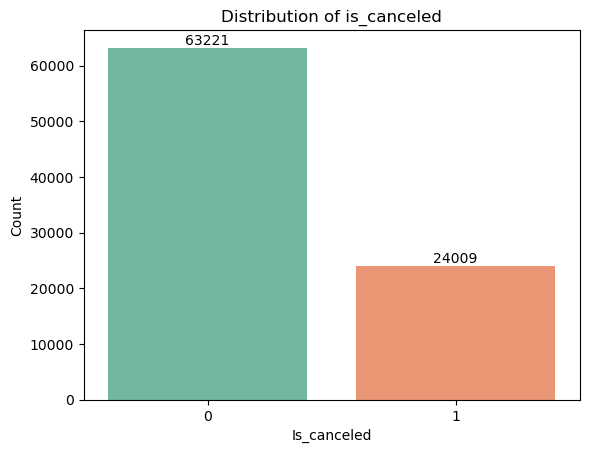

In [31]:
# Distribution Target column

class Column_Distribution:
    def __init__(self,dataframe):
        self.df = dataframe
    def Distribution(self,column_name):
        ax  = sns.countplot(data = self.df, x= column_name, palette= 'Set2')
        for i in ax.containers:
            ax.bar_label(i)
        plt.title(f'Distribution of {column_name}')
        plt.xlabel(column_name.capitalize())
        plt.ylabel('Count')
        plt.show()
plotter = Column_Distribution(df)
plotter.Distribution('is_canceled')

## Distribution of Numeric Features

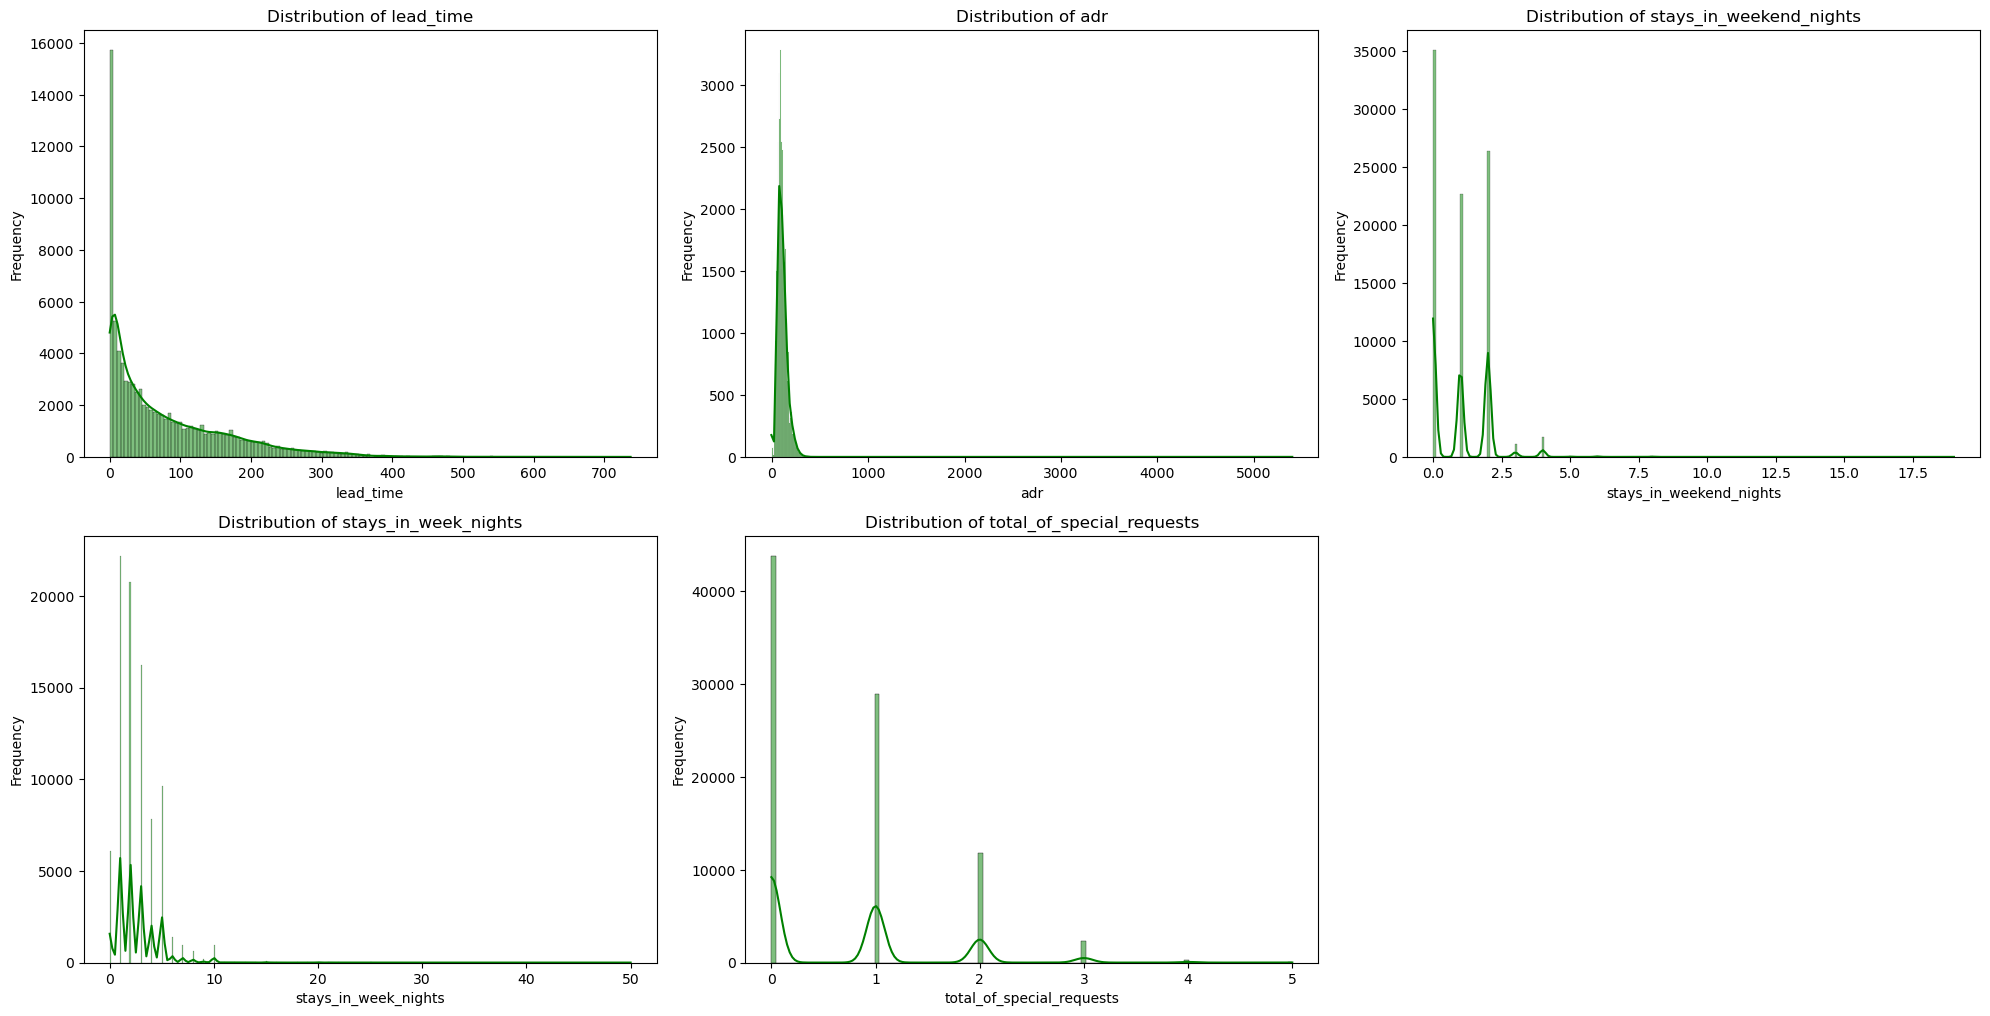

In [33]:
# Feature to view the distribution

columns = ['lead_time','adr','stays_in_weekend_nights','stays_in_week_nights', 'total_of_special_requests']

# Create a function to view distribution of numerical features

def histogram(column_name):
    plt.figure(figsize=(20,25))
    for i,col in enumerate(columns,1):
        plt.subplot(5,3,i)
        sns.histplot(data=df, x=df[col], kde=True,color='green')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Calling function
histogram(columns)

In [34]:
# Skewness and kurtosis of Numerical Columns

print('The Skewness of Numerical Features:\n',df[columns].skew())
print('\n The Kurtosis of Numerical Features:\n',df[columns].kurtosis())

The Skewness of Numerical Features:
 lead_time                     1.430752
adr                          11.017880
stays_in_weekend_nights       1.340319
stays_in_week_nights          2.575451
total_of_special_requests     1.082397
dtype: float64

 The Kurtosis of Numerical Features:
 lead_time                      2.123263
adr                          992.178253
stays_in_weekend_nights        7.073996
stays_in_week_nights          20.095556
total_of_special_requests      0.819515
dtype: float64


## Boxplot for Outliers

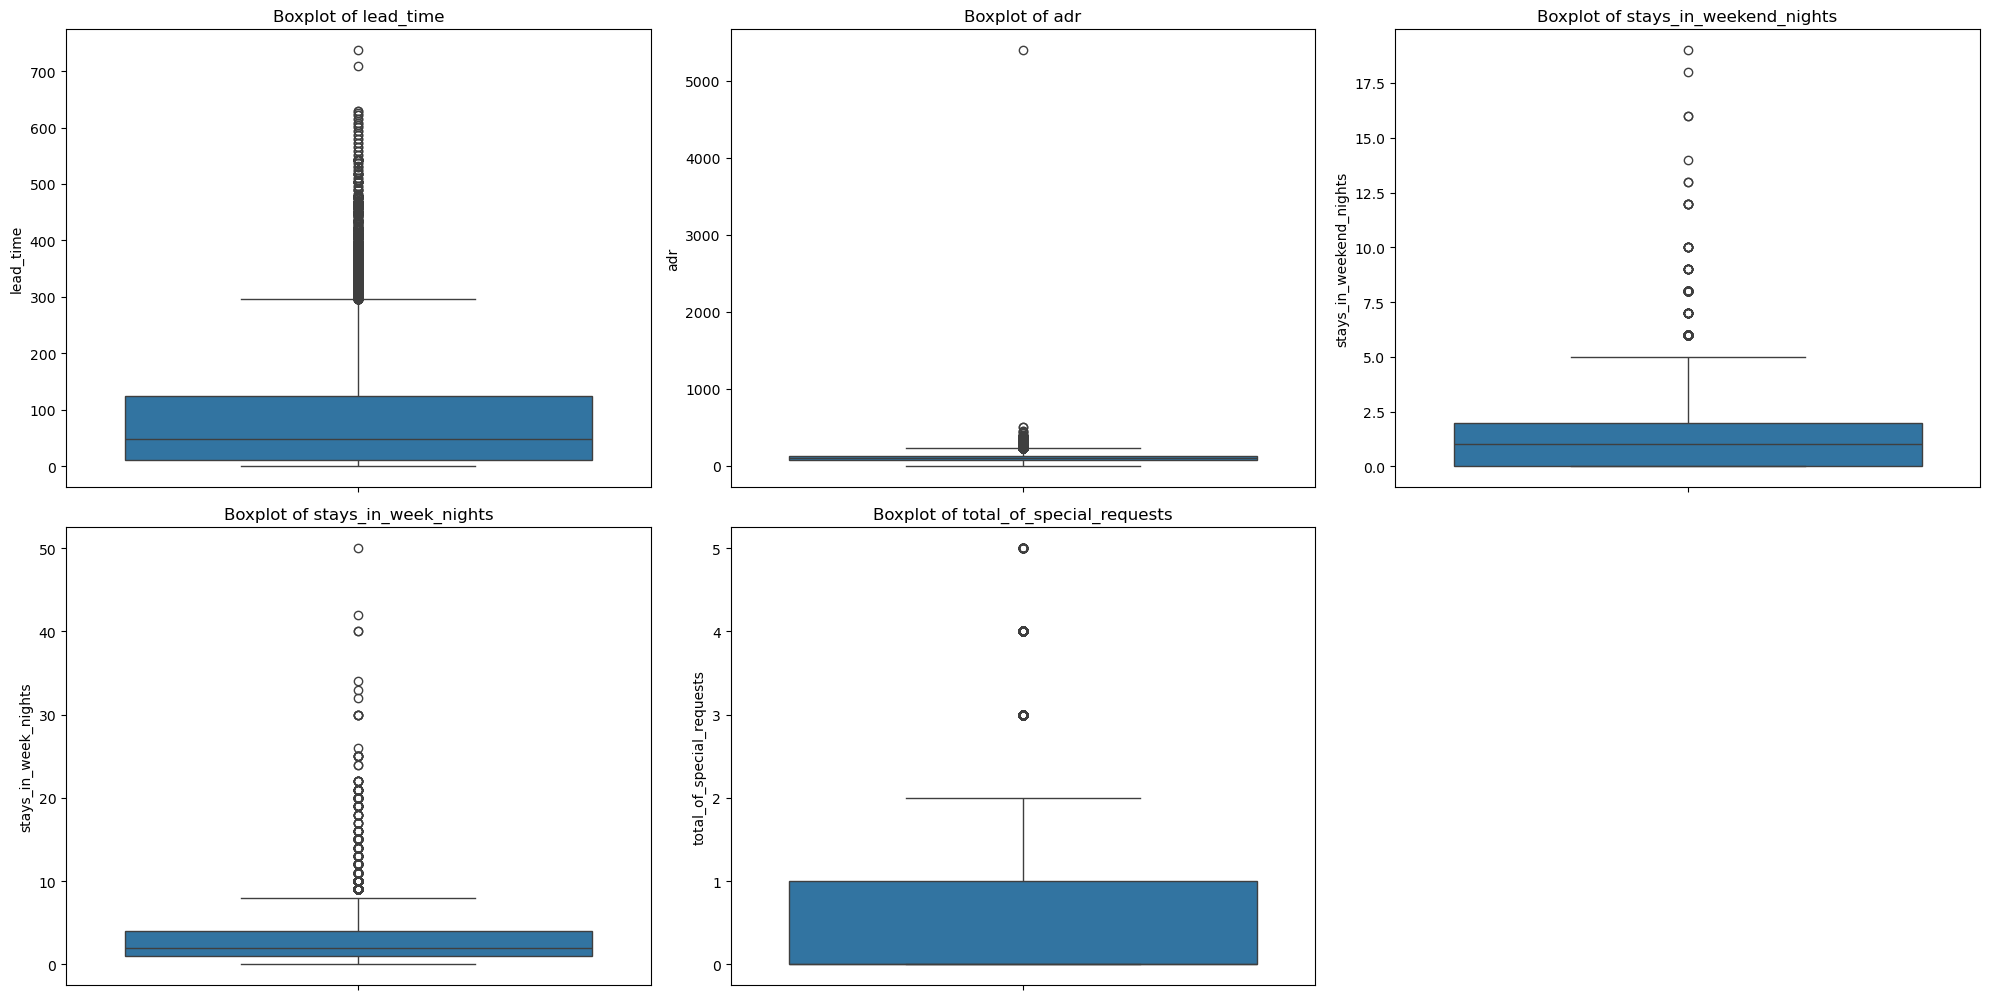

In [36]:
# Create a function to view outliers in boxplot

def boxplot(column_name):
    plt.figure(figsize=(20,25))
    for i,col in enumerate (columns,1):
        plt.subplot(5,3,i)
        sns.boxplot(df[col])
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

boxplot(columns)

    


## IQR For Removing Outliers

In [38]:
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 -Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    df[col] = df[col].clip(lower = lower_bound, upper = upper_bound)

## Boxplot After Removing Outliers

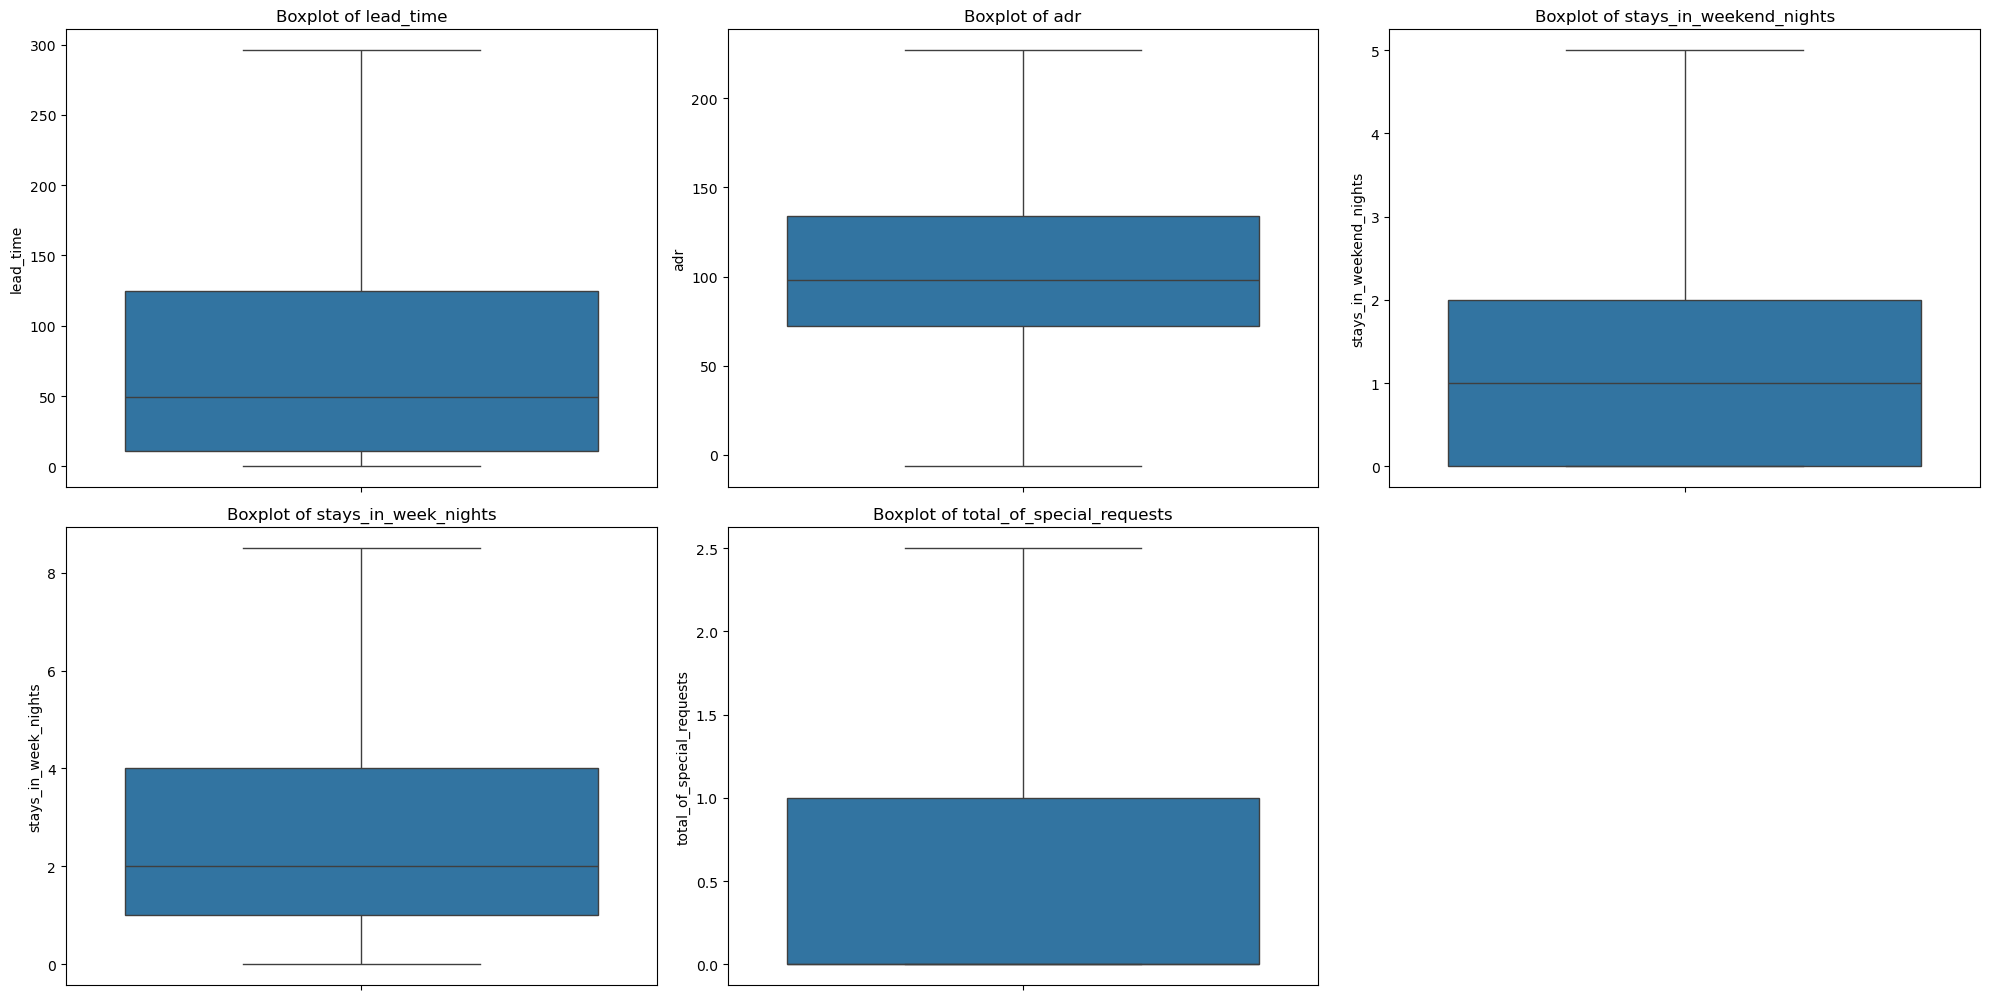

In [40]:
boxplot(columns)

## Distribution After Removing Outliers

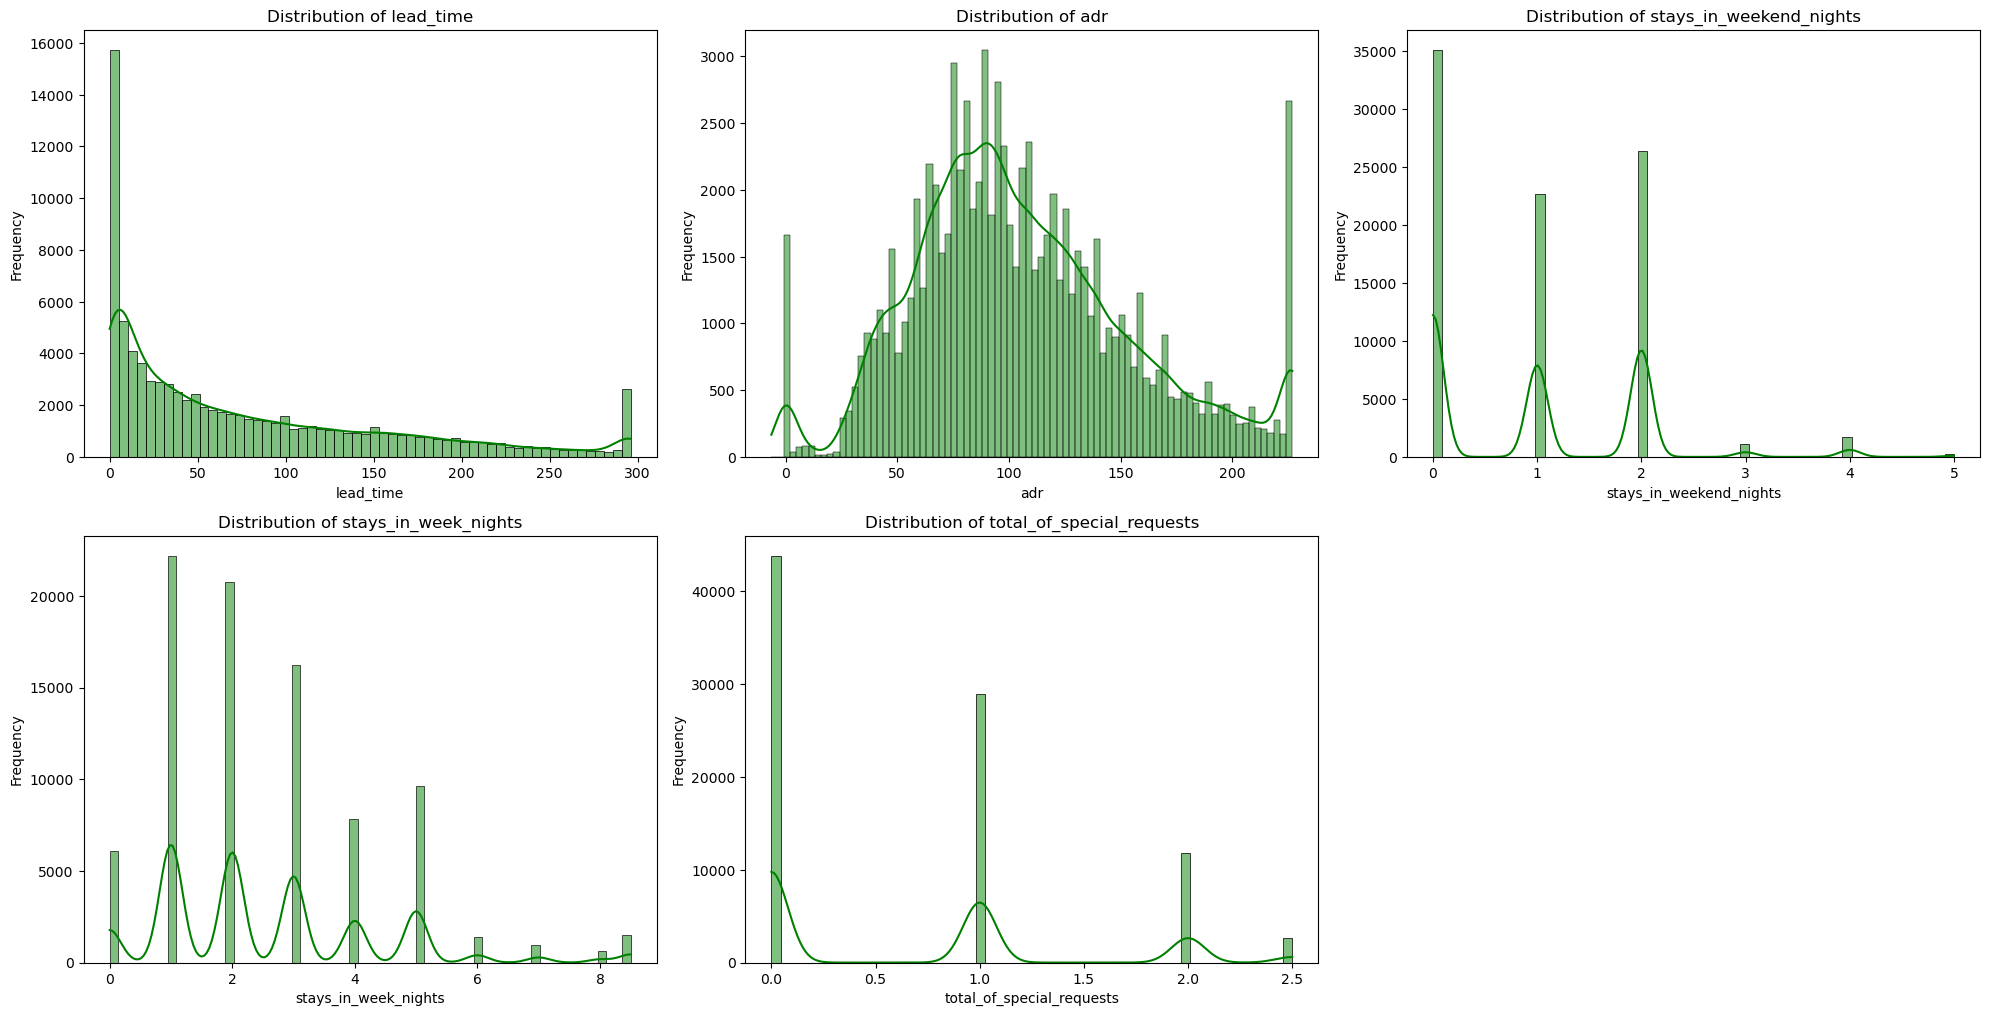

In [42]:
histogram(columns)

 ## Heatmap

<Axes: >

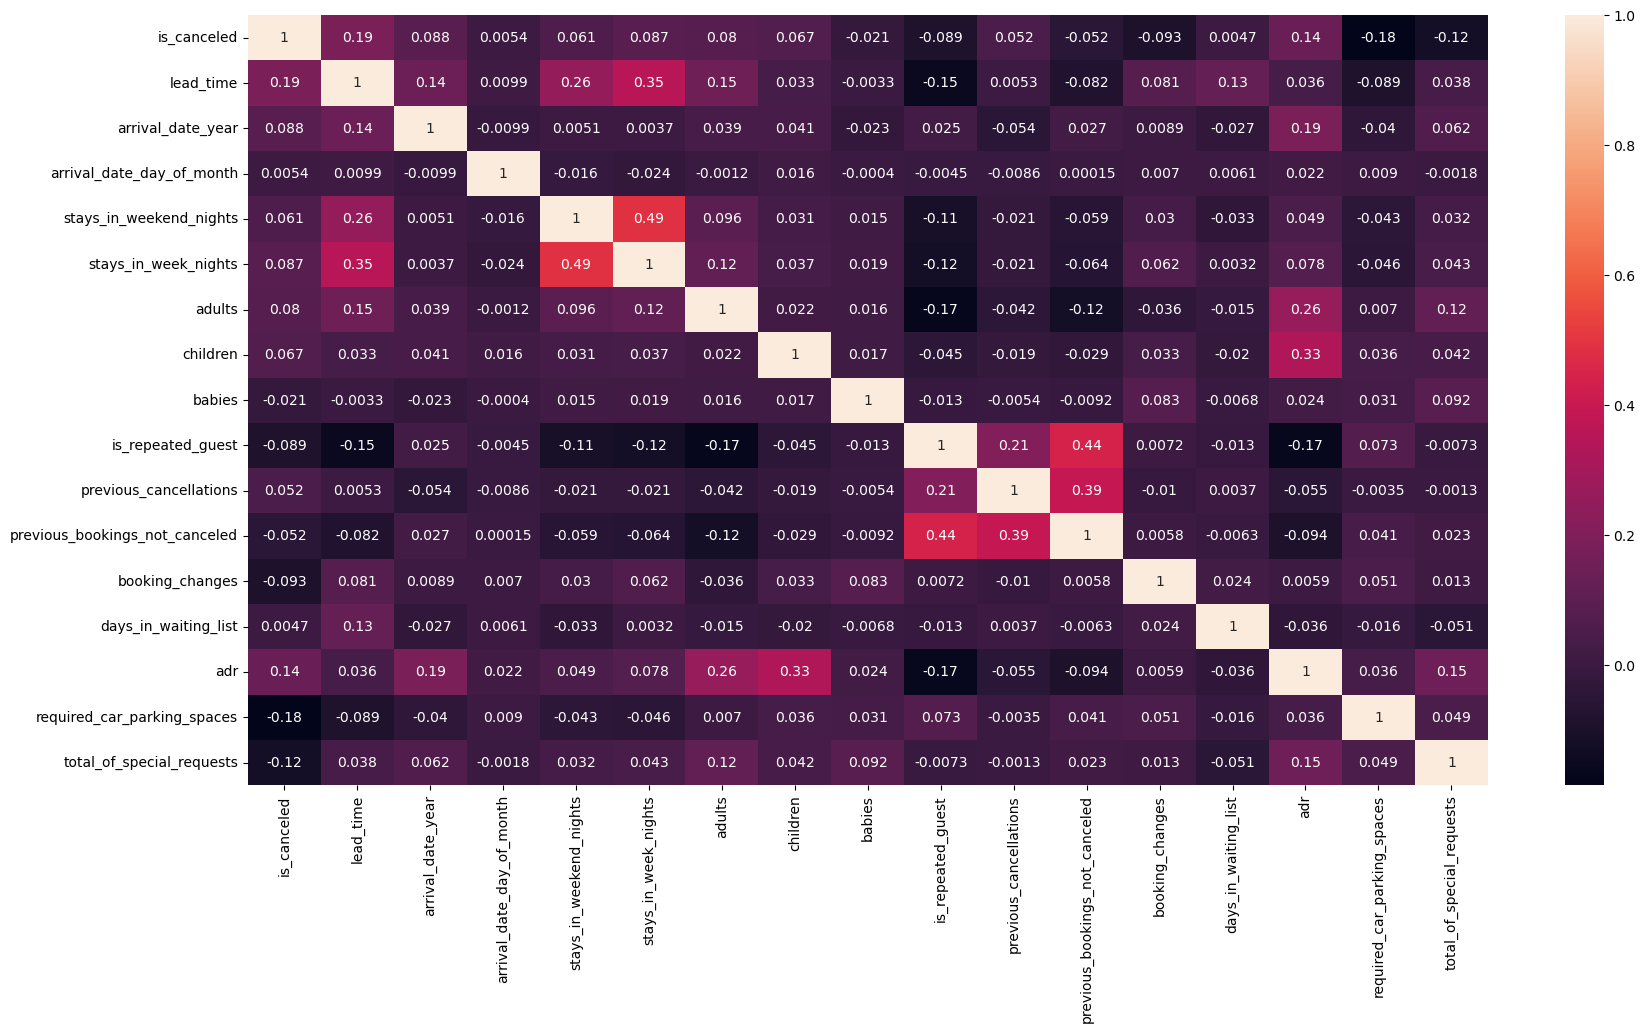

In [44]:
# Collinearity between the features

corr_matrix = df.select_dtypes(include='number').corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True)

- Overall: Cancellations are weakly correlated with these feature - no strong single predictor but patterns exist.
- Multicollinearity : stays in weekend nights and stays in week night have correlation of .49. Both are weakly correlated with target column.
  previous cancellations and  previous booking not canceled have correlation of 0.39.
- is repeated guest and previous bookings not canceled have correlation of 0.44
- One of the feature with multicollinearity has to be dropped.
- adult, children and babies are less correlated with the target feature
- arrival day of month and days in waiting list have very low correlation with is_canceled of .0054 and .0047
  
  

## Percentage of Hotel Booking Cancellation

Text(0.5, 1.0, 'Hotel Booking percentage')

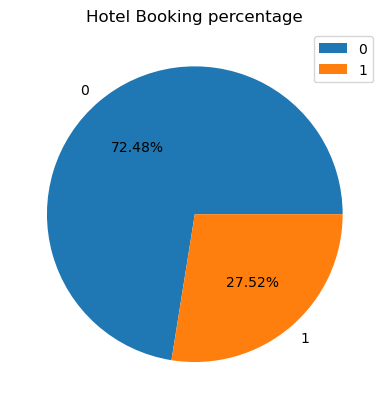

In [47]:
plt.pie(df['is_canceled'].value_counts(), autopct='%1.2f%%',labels=[0,1])
plt.legend()
plt.title('Hotel Booking percentage')

 Around 72.48% booking are not canceled by guests but around 27.53% booking are canceled by guests.

## Most preffered Hotel by guest

Text(0.5, 1.0, 'Most preffered Hotel')

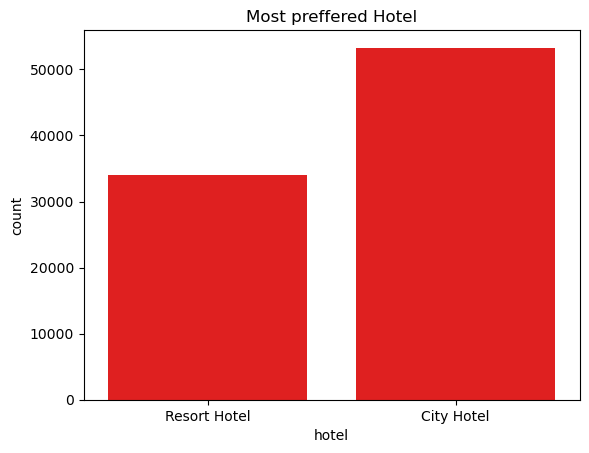

In [50]:
sns.countplot(x='hotel', data=df,color='r')
plt.title('Most preffered Hotel')

I found out that guests prefer  City Hotel.This insight is useful for the stakeholder to check which hotel is performing best and they can invest more capitals in that.

## Type of meal most preffered by guests

C:\Users\HP\AppData\Local\Temp\ipykernel_5096\3547984183.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='meal',data=df, palette='bright')


Text(0.5, 1.0, 'Most preffered meal type')

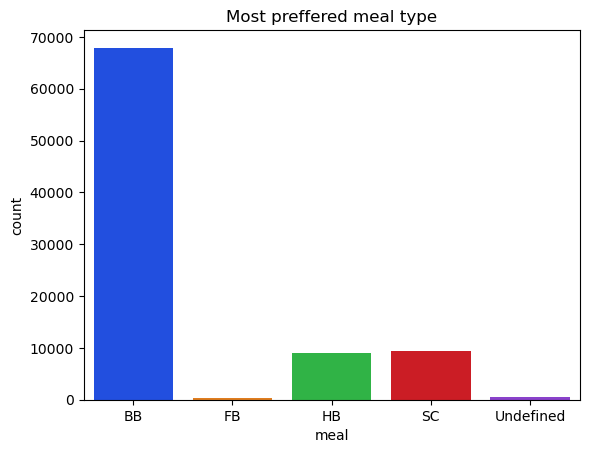

In [53]:
sns.countplot(x='meal',data=df, palette='bright')
plt.title('Most preffered meal type')

After visualizing the above chart we can see that BB - (Bed and Breakfast) is the most preffered meal type by guests.so they can arrange raw material for this meal in advance and deliver the meal without any delay.

## Year with Most Bookings

Text(0.5, 1.0, 'Number of booking across year')

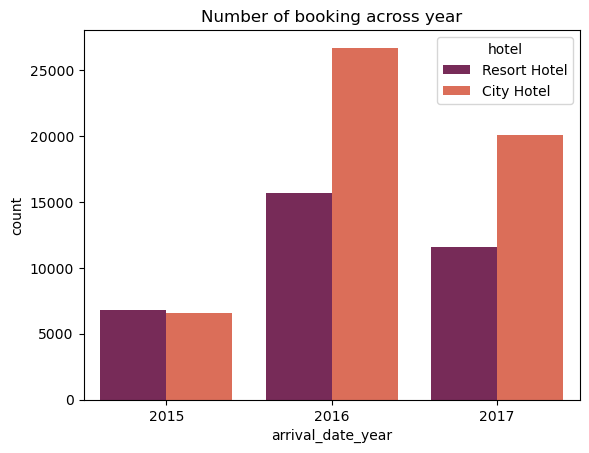

In [56]:
sns.countplot(x= 'arrival_date_year',data=df, hue='hotel', palette='rocket')
plt.title('Number of booking across year')

From above insight I found out that hotel was booked most times in year 2016.Above insight shows that number of booking was decreased after year 2016.  One way to do this is ask for feedbacks from guests and have a meeting with old employees who else were serving in the year 2016 to increase booking.

## Most Booking Month in each hotel type

Text(0.5, 1.0, 'Number of booking across a month')

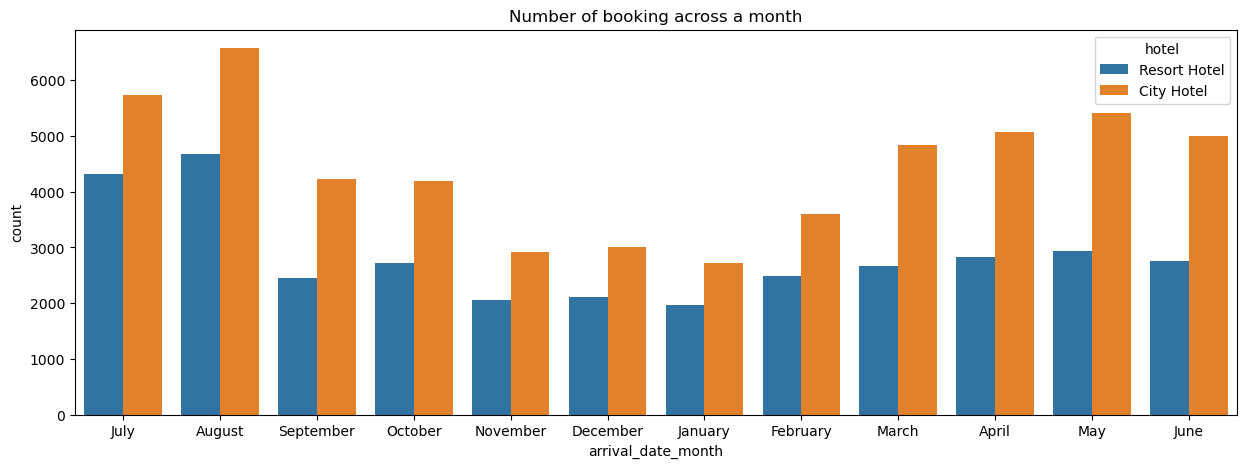

In [59]:
plt.figure(figsize=(15,5))
sns.countplot(x='arrival_date_month',data=df,hue='hotel')
plt.title('Number of booking across a month')

Above insight shows that August and July ware 2 most busy months in compare to others.so hotel can use this insight to arrange everything in advance and welcome their guest in the best way possible and hotel can also run some promotional offer in these 2 months to attract more guests.

## Which distribution channel is most used in booking

Text(0.5, 1.0, 'Most Booking Distribution channels by Guests')

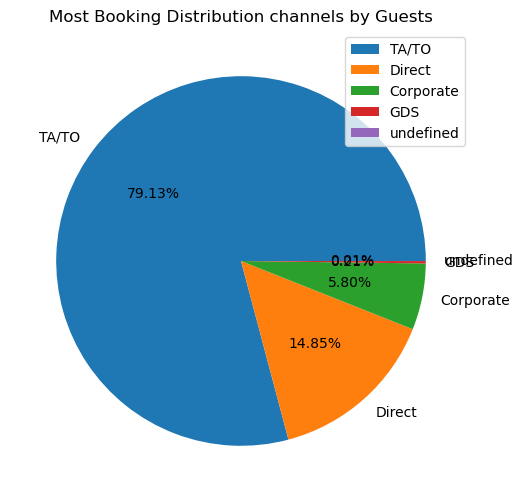

In [62]:
plt.figure(figsize=(15,6))
plt.pie(df['distribution_channel'].value_counts(),autopct='%1.2f%%',labels=['TA/TO','Direct','Corporate','GDS','undefined'])
plt.legend()
plt.title('Most Booking Distribution channels by Guests')

From the above insight it is clear that TA/TO (travel agents/Tour operators) is most used distribution channel by guests.Hotels can run promotional offers to motivate other channels to contribute more in bookings.

## Most preffered Room type by Guests

C:\Users\HP\AppData\Local\Temp\ipykernel_5096\486333870.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['reserved_room_type'], order=df['reserved_room_type'].value_counts().index, palette='cool')


Text(0.5, 1.0, 'Preffered room type by guests')

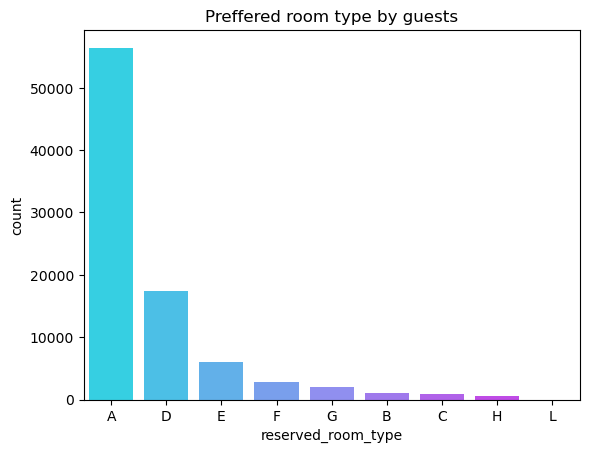

In [65]:
sns.countplot(x=df['reserved_room_type'], order=df['reserved_room_type'].value_counts().index, palette='cool')
plt.title('Preffered room type by guests')

By observing the above chart we can understand that the room type A most preffered by the guests while booking the hotel.As it is clear that room type A is most used hotel should increase the number of A type room to maximize the revenue.

## Most Assigned Room type

C:\Users\HP\AppData\Local\Temp\ipykernel_5096\1650217746.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['assigned_room_type'],order = df['assigned_room_type'].value_counts().index, palette='hot')


Text(0.5, 1.0, 'Assigned Room type')

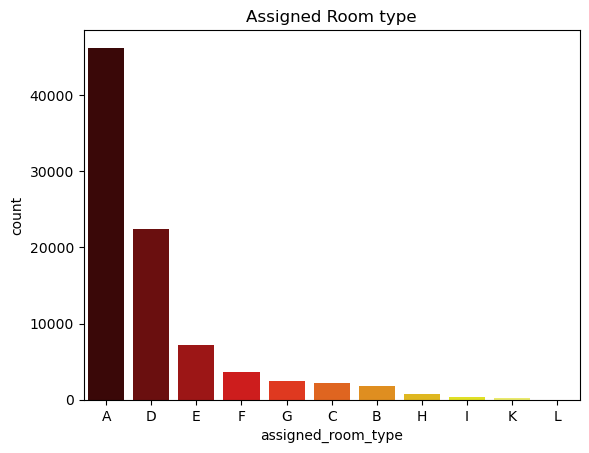

In [68]:
sns.countplot(x = df['assigned_room_type'],order = df['assigned_room_type'].value_counts().index, palette='hot')
plt.title('Assigned Room type')

In the above chart we saw that around 55,000 guests preffered room type A but 45,000 people were assigned A type room. This could be a reason to cancel the bookings. Hotel could increase A type room to decrease cancellation.

## Percentage of Repeated guest

Text(0.5, 1.0, 'Repeated guests')

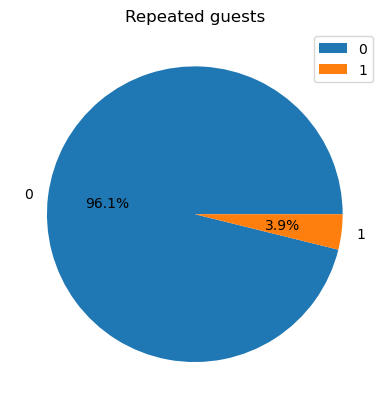

In [71]:
plt.pie(df['is_repeated_guest'].value_counts(), labels=[0,1], autopct='%1.1f%%')
plt.legend()
plt.title('Repeated guests')

From the above insight we can see that 3.9% guests are repeated guests.We can see that number of repeated guests is very low and it shows negative growth of the hotel. Hotel can offer loyality discount to their guests to increase repeated guests and also ask customers feedback to improve bookings.

## Customer type with most booking 

C:\Users\HP\AppData\Local\Temp\ipykernel_5096\949438926.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:blue'` for the same effect.

  sns.countplot(y=df['customer_type'], color='blue',hue=df['hotel'])


Text(0.5, 1.0, 'Customer type Booking Count')

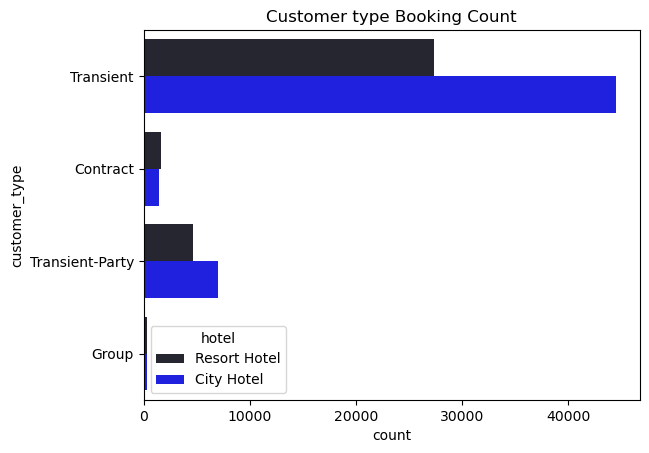

In [74]:
sns.countplot(y=df['customer_type'], color='blue',hue=df['hotel'])
plt.title('Customer type Booking Count')

We can see that Transient customer type has most number of bookings.Hotel can run promotional offers to increase the number of bookings over other categories.

## Market Segment with Most Booking

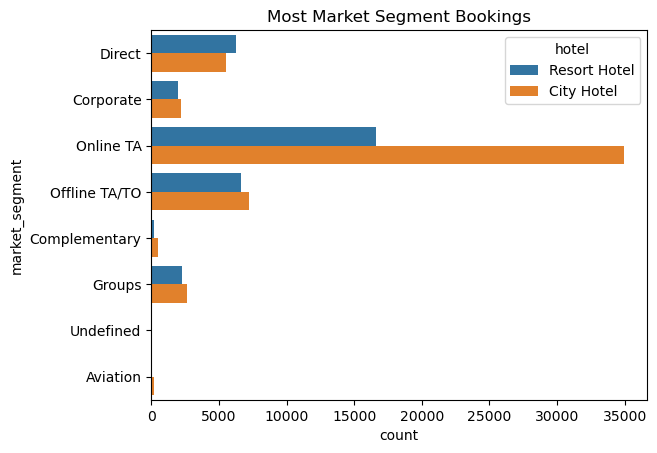

In [77]:
sns.countplot(data =df, y='market_segment', hue='hotel')
plt.title('Most Market Segment Bookings')
plt.show()


Above insight shows that Online TA (Travel Agent) has the most bookings. Especially large bookings for City Hotel

## Most Used Deposit Type

C:\Users\HP\AppData\Local\Temp\ipykernel_5096\3740041736.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='deposit_type',data=df,palette='colorblind')


Text(0.5, 1.0, 'Deposit type Bookings')

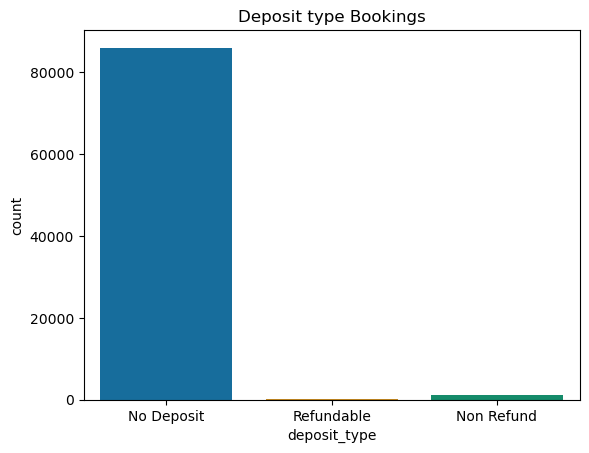

In [80]:
sns.countplot(x='deposit_type',data=df,palette='colorblind')
plt.title('Deposit type Bookings')

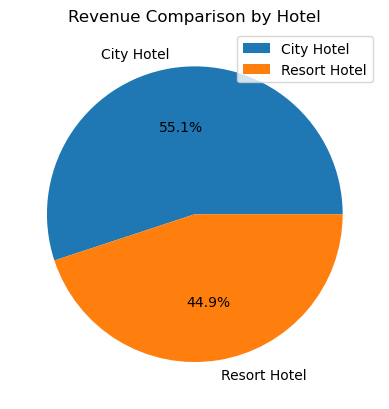

In [81]:
# Calculating the Revenue generated
df['revenue'] = df['adr'] * (df['stays_in_weekend_nights'] + df['stays_in_week_nights'])

# Hotel which generates more revenue
revenue_by_hotel = df.groupby('hotel')['revenue'].sum()
plt.pie(df.groupby('hotel')['revenue'].sum(), autopct='%1.1f%%', labels =revenue_by_hotel.index)
plt.legend()
plt.title('Revenue Comparison by Hotel')
plt.show()


From the above insight it is clear that City hotel has more share in revenue over Resort hotel.Stakehoders could improve the service of resort hotel so that people stay more in resort hotel and increase the revenue.

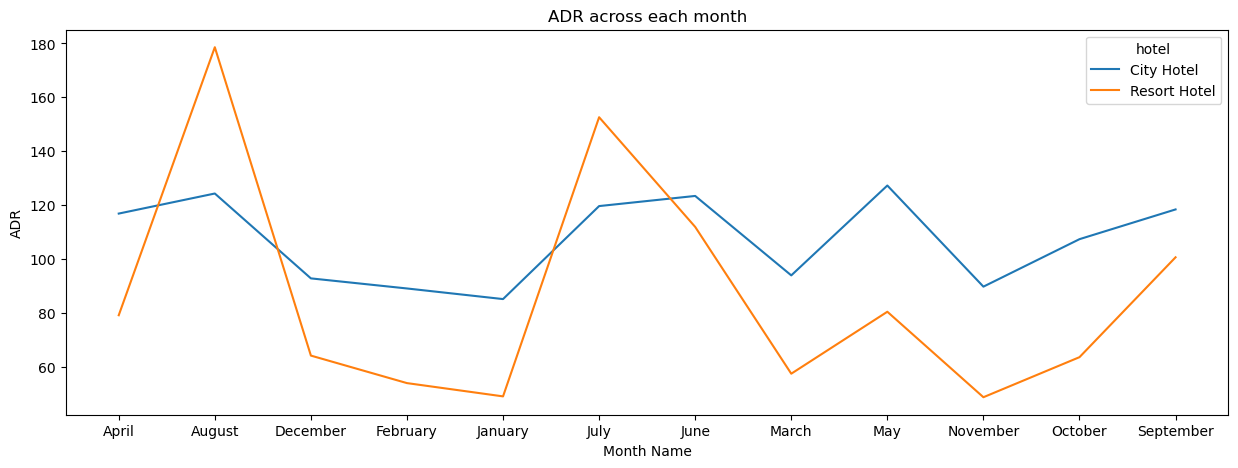

In [83]:
booking_months = df.groupby(['arrival_date_month','hotel'])['adr'].mean().reset_index()
plt.figure(figsize=(15,5))
sns.lineplot(x= booking_months['arrival_date_month'], y = booking_months['adr'], hue = booking_months['hotel'])
plt.title('ADR across each month')
plt.xlabel('Month Name')
plt.ylabel('ADR')
plt.show()

It is clear that City Hotel generates more revenue in May months in comparison to other months.
 Resort Hotel generates more revenue in between July and August months.

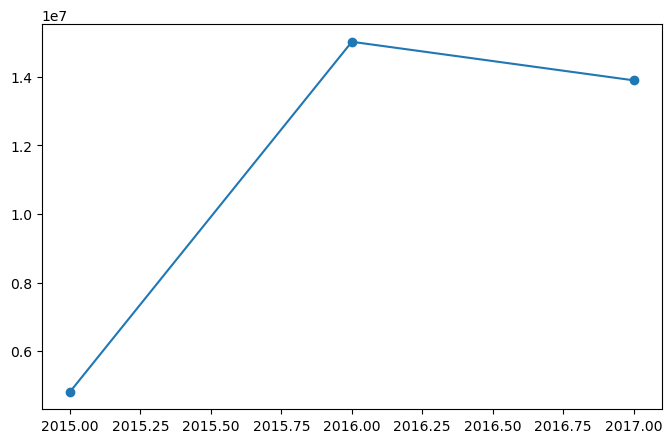

In [85]:
# Group revenue by year
df['arrival_date_year'] = df['arrival_date_year'].astype(int)
revenue_year = df.groupby('arrival_date_year')['revenue'].sum().reset_index()

# Plot the line chart
plt.figure(figsize=(8,5))
plt.plot(revenue_year['arrival_date_year'], revenue_year['revenue'], marker='o')

In [86]:
revenue_year = df.groupby('arrival_date_year')['revenue'].sum().reset_index()
revenue_year

,arrival_date_year,revenue
0,2015,4.814057e+06
1,2016,1.501850e+07
2,2017,1.389450e+07


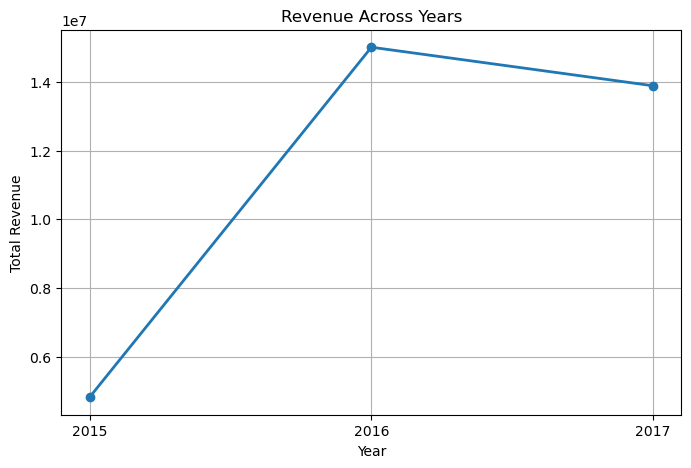

In [87]:
import matplotlib.pyplot as plt

# Group revenue by year
revenue_year = df.groupby('arrival_date_year')['revenue'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.plot(revenue_year['arrival_date_year'], revenue_year['revenue'], marker='o', linewidth=2)
plt.title('Revenue Across Years')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.grid(True)

# Force x-axis to show only integer years
plt.xticks(revenue_year['arrival_date_year'])

plt.show()


In [88]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,revenue
0,Resort Hotel,0,296,2015,July,1,0,0.0,2,0,...,C,C,3,No Deposit,0,Transient,0.00,0,0.0,0.00
1,Resort Hotel,0,296,2015,July,1,0,0.0,2,0,...,C,C,4,No Deposit,0,Transient,0.00,0,0.0,0.00
2,Resort Hotel,0,7,2015,July,1,0,1.0,1,0,...,A,C,0,No Deposit,0,Transient,75.00,0,0.0,75.00
3,Resort Hotel,0,13,2015,July,1,0,1.0,1,0,...,A,A,0,No Deposit,0,Transient,75.00,0,0.0,75.00
4,Resort Hotel,0,14,2015,July,1,0,2.0,2,0,...,A,A,0,No Deposit,0,Transient,98.00,0,1.0,196.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87225,City Hotel,0,23,2017,August,30,2,5.0,2,0,...,A,A,0,No Deposit,0,Transient,96.14,0,0.0,672.98
87226,City Hotel,0,102,2017,August,31,2,5.0,3,0,...,E,E,0,No Deposit,0,Transient,225.43,0,2.0,1578.01
87227,City Hotel,0,34,2017,August,31,2,5.0,2,0,...,D,D,0,No Deposit,0,Transient,157.71,0,2.5,1103.97
87228,City Hotel,0,109,2017,August,31,2,5.0,2,0,...,A,A,0,No Deposit,0,Transient,104.40,0,0.0,730.80


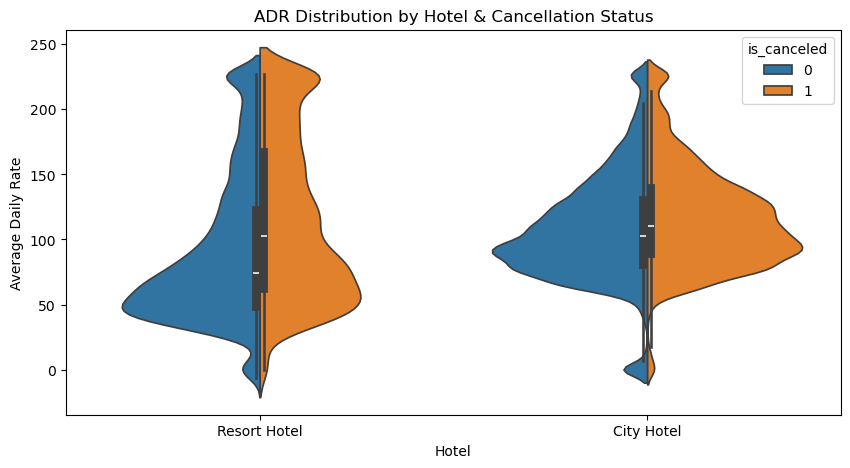

In [89]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df, x='hotel', y='adr', hue='is_canceled', split=True)
plt.title('ADR Distribution by Hotel & Cancellation Status')
plt.xlabel('Hotel')
plt.ylabel('Average Daily Rate')
plt.show()

Resort Hotels :

   - Non-canceled bookings are concentrated around lower to mid ADR values.

   - Canceled bookings are spread across the range but are more frequent at higher ADRs.

   - Suggests that higher pricing increases cancellation risk for resort hotels.

City Hotels :

   - ADRs are generally higher compared to resort hotels.

   - Non-canceled bookings cluster around mid ADR range (~80–120).

   - Canceled bookings dominate the higher ADR values, again showing price sensitivity.

Overall Trends :

   - Higher ADR strongly correlates with cancellations in both hotel types.

   -  Guests are more likely to honor bookings when ADR is moderate rather than very high.

   

Text(0.5, 1.0, 'Distribution of adr by Cancellation')

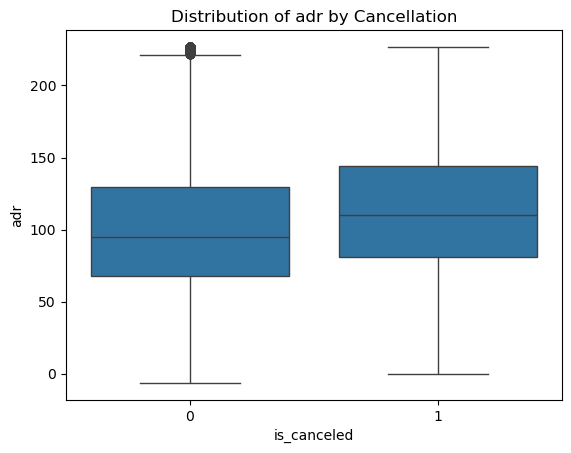

In [91]:
sns.boxplot(data=df, x='is_canceled', y='adr')
plt.title('Distribution of adr by Cancellation')

Median ADR:

  - Canceled bookings (1) have a higher median ADR than non-canceled bookings (0).

  - Suggests that higher ADR values are more likely associated with cancellations.

Spread/Variability:

  - Both groups show wide ADR variation, but cancellations have a wider interquartile range (IQR).

  - Indicates more fluctuation in ADR for canceled bookings.

Outliers:

  - Non-canceled bookings (0) show a few high ADR outliers, but canceled bookings (1) extend similarly high.

  - Implies that extreme ADR values appear in both groups, though more cancellations occur at higher ADR levels.

Overall Insight:

  - Price sensitivity is evident: guests tend to cancel more often when ADR is high.

  - Moderate ADR values correspond to lower cancellation rates, making pricing strategy crucial for reducing cancellations.

In [93]:
# Removing multicollinearity features and redudant features.
df.drop(columns=['arrival_date_day_of_month','days_in_waiting_list','babies',
                 'children','previous_bookings_not_canceled'], inplace= True, axis=1)

In [94]:
numerical_cols = df.select_dtypes(include='number').columns

In [95]:
df.shape

(87230, 23)

In [96]:
# Encoding the categorical data
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])


## Train Test Split

In [98]:
X = df.drop(columns=['is_canceled','revenue'],axis=1)
y = df['is_canceled']

In [99]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=.30, random_state=42)
print('The shape of X_train:', X_train.shape)
print('The shape of y_train:', y_train.shape)
print('The shape of X_test:', X_test.shape)
print('The shape of y_test:', y_test.shape)

The shape of X_train: (61061, 21)
The shape of y_train: (61061,)
The shape of X_test: (26169, 21)
The shape of y_test: (26169,)


In [100]:
numerical_cols = ['lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'is_repeated_guest', 'previous_cancellations',
       'booking_changes', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests']

# Initialize the scaler
scaler = StandardScaler()

# Scaling train data and test data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.fit_transform(X_test[numerical_cols])

# Apply Smote on Training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('The shape of X_train_smote:',X_train_smote.shape)
print('The shape of y_train_smote:',y_train_smote.shape)
print()
print('Before Smote:',y_train.value_counts())
print('\n After Smote:',y_train_smote.value_counts())

The shape of X_train_smote: (88298, 21)
The shape of y_train_smote: (88298,)

Before Smote: is_canceled
0    44149
1    16912
Name: count, dtype: int64

 After Smote: is_canceled
0    44149
1    44149
Name: count, dtype: int64


In [101]:
# Defining a function for model prediction
def evaluate_model(model):
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)

    train_score = model.score(X_train_smote, y_train_smote)
    acc = accuracy_score(y_test,y_pred)
    conf = confusion_matrix(y_test,y_pred)
    clf_report = classification_report(y_test,y_pred)

    print(f"Model: {model.__class__.__name__}")
    print(f"Training score: {train_score:.4f}")
    print(f"Accuracy Score: {acc:.4f}")
    print("\nConfusion Matrix:\n", conf)
    print("\nClassification Report:\n", clf_report)
    
    return model, y_pred

    

## Logistic Regression

In [102]:
lr = LogisticRegression( random_state=42)
model_lr, y_pred_lr = evaluate_model(lr)

Model: LogisticRegression
Training score: 0.7242
Accuracy Score: 0.6912

Confusion Matrix:
 [[12660  6412]
 [ 1668  5429]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.66      0.76     19072
           1       0.46      0.76      0.57      7097

    accuracy                           0.69     26169
   macro avg       0.67      0.71      0.67     26169
weighted avg       0.77      0.69      0.71     26169



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## KNN

In [103]:
knn = KNeighborsClassifier()
model_knn, y_pred_knn = evaluate_model(knn)

Model: KNeighborsClassifier
Training score: 0.8798
Accuracy Score: 0.7291

Confusion Matrix:
 [[13632  5440]
 [ 1648  5449]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.71      0.79     19072
           1       0.50      0.77      0.61      7097

    accuracy                           0.73     26169
   macro avg       0.70      0.74      0.70     26169
weighted avg       0.79      0.73      0.74     26169



## Decision Tree Classifier

In [104]:
dc = DecisionTreeClassifier(max_depth=10, min_samples_split=50, random_state=42)
model_dc, y_pred_dc = evaluate_model(dc)

Model: DecisionTreeClassifier
Training score: 0.8143
Accuracy Score: 0.6349

Confusion Matrix:
 [[10229  8843]
 [  710  6387]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.54      0.68     19072
           1       0.42      0.90      0.57      7097

    accuracy                           0.63     26169
   macro avg       0.68      0.72      0.63     26169
weighted avg       0.80      0.63      0.65     26169



## Random Forest Classifier

In [105]:
rfc = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,max_features='sqrt', random_state=42)
model_rfc, y_pred_rfc = evaluate_model(rfc)

Model: RandomForestClassifier
Training score: 0.8342
Accuracy Score: 0.6740

Confusion Matrix:
 [[11245  7827]
 [  704  6393]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.59      0.72     19072
           1       0.45      0.90      0.60      7097

    accuracy                           0.67     26169
   macro avg       0.70      0.75      0.66     26169
weighted avg       0.81      0.67      0.69     26169



Although KNN showed higher accuracy, I chose Random Forest Classifier as it generalizes better on large datasets, handles imbalance effectively, and provides feature importance for interpretability. The model achieved Accuracy = 67.4%, Precision = 0.76, Recall = 0.47, and F1-score = 0.59, making it a more robust choice for this problem.

## identifying Significant variables affecting Cancellation

In [108]:
importances = rfc.feature_importances_
feature_importances_df = pd.DataFrame({'Feature':X.columns,'Importances':importances}).reset_index(drop=True)
feature_importances_df = feature_importances_df.sort_values(by='Importances',ascending=False)

In [186]:
print('The top 10 significant features are:')
feature_importances_df.head(10)

The top 10 significant features are:


,Feature,Importances
1,lead_time,0.181290
8,country,0.130692
20,total_of_special_requests,0.124693
9,market_segment,0.117718
19,required_car_parking_spaces,0.097252
15,booking_changes,0.062224
5,stays_in_week_nights,0.059305
17,customer_type,0.049120
18,adr,0.033092
10,distribution_channel,0.025082


## Hyperparameter tuning for RandomForestClassifier

In [112]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf, param_distributions= param_dist,
    n_iter=10, cv=3, scoring='f1', verbose=2, n_jobs=-1, random_state=42)

random_search.fit(X_train_smote, y_train_smote)
print('Best Parameters:', random_search.best_params_)

best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test,y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}
Accuracy: 0.6718254423172456
Confusion Matrix:
 [[11106  7966]
 [  622  6475]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.58      0.72     19072
           1       0.45      0.91      0.60      7097

    accuracy                           0.67     26169
   macro avg       0.70      0.75      0.66     26169
weighted avg       0.81      0.67      0.69     26169

